# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [1]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 10.1 MB/s eta 0:00:00


In [2]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

In [3]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [4]:

def fitness_func(ga_instance, solution, solution_idx):
    # La solución (cromosoma) que el algoritmo genético propone.
    # Cada valor en 'solution' representa una prioridad para una tarea.
    # 'ga_instance' es la instancia del algoritmo genético.
    # 'solution_idx' es el índice de la solución actual en la población.

    # np.argsort(solution) devuelve los índices que ordenarían el array 'solution'.
    # Esto transforma las prioridades aleatorias en un orden secuencial de tareas (de menor a mayor prioridad).
    orden_tareas = np.argsort(solution)

    # Inicializa el tiempo actual de la obra en 0.
    tiempo_actual = 0
    # Array para llevar un registro de cuántos operarios están trabajando en cada día.
    # Se inicializa con un tamaño grande (1000 días) para asegurar que haya espacio suficiente.
    operarios_dia = np.zeros(1000)
    # Diccionario para almacenar el día de finalización de cada tarea.
    fin_tareas = {}

    # Itera sobre cada tarea en el orden determinado por el algoritmo genético.
    for tarea_id in orden_tareas:
        # Extrae la duración y los operarios necesarios para la tarea actual
        # del diccionario global 'TASAS_OBRA'.
        duracion, operarios_necesarios = TASAS_OBRA[tarea_id]

        # Inicializa el día de inicio potencial para la tarea en 0.
        dia_inicio = 0
        # Bucle para encontrar el día de inicio más temprano posible para la tarea actual.
        while True:
            # Bandera para verificar si la tarea puede iniciarse en 'dia_inicio'.
            disponible = True
            # Itera sobre cada día que la tarea duraría, a partir de 'dia_inicio'.
            for d in range(dia_inicio, dia_inicio + duracion):
                # Comprueba si añadir los operarios de esta tarea excede el límite 'MAX_OPERARIOS'
                # en cualquiera de los días de su duración.
                if operarios_dia[d] + operarios_necesarios > MAX_OPERARIOS:
                    disponible = False # Si excede, no está disponible.
                    dia_inicio += 1   # Intenta empezar la tarea un día después.
                    break             # Rompe el bucle interno y vuelve a intentar con el nuevo 'dia_inicio'.
            # Si la tarea está disponible para iniciar en 'dia_inicio' (no hubo sobrecarga de operarios).
            if disponible:
                break # Rompe el bucle 'while True' y avanza a la siguiente tarea.

        # Una vez que se encuentra un 'dia_inicio' válido, asigna los operarios a esos días.
        # Suma los operarios necesarios a 'operarios_dia' para cada día que dura la tarea.
        for d in range(dia_inicio, dia_inicio + duracion):
            operarios_dia[d] += operarios_necesarios

        # Registra el día en que la tarea finaliza.
        fin_tareas[tarea_id] = dia_inicio + duracion
        # Actualiza el 'tiempo_actual' de la obra, tomando el máximo entre el tiempo actual
        # y el día de finalización de la tarea recién programada.
        tiempo_actual = max(tiempo_actual, dia_inicio + duracion)

    # El Makespan es el tiempo total de la obra, es decir, el día en que la última tarea finaliza.
    makespan = tiempo_actual

    # Esta es una verificación de seguridad adicional. Aunque la lógica del 'while' debería evitarlo,
    # si por alguna razón la asignación de operarios superara 'MAX_OPERARIOS' en algún día,
    # se aplica una penalización drástica para que esta solución sea muy poco apta.
    if np.any(operarios_dia > MAX_OPERARIOS):
        return 0.0000000001 # Un fitness muy bajo para penalizar soluciones inválidas.

    # El objetivo es minimizar el Makespan, por lo tanto, el fitness se calcula como 1 dividido por el Makespan.
    # Un Makespan más pequeño resultará en un fitness más alto (maximización).
    if makespan == 0:
        return 0.0 # Evita la división por cero si Makespan es 0 (ej. no hay tareas o duración 0).
    
    return 1.0 / makespan


In [5]:

# Configuración del Algoritmo Genético
ga_instance = pygad.GA(
    num_generations=100,          # Número total de iteraciones (generaciones)
    num_parents_mating=10,        # Número de padres que se seleccionan para reproducirse
    fitness_func=fitness_func,    # Función que evalúa qué tan buena es cada solución
    sol_per_pop=50,               # Cantidad de individuos en cada generación
    num_genes=NUM_TAREAS,         # Cada individuo tiene 10 genes (uno por cada tarea)
    init_range_low=0,             # Valor mínimo inicial para los genes
    init_range_high=NUM_TAREAS,    # Valor máximo inicial para los genes
    random_mutation_min_val=0,    # Valor mínimo para cambios por mutación
    random_mutation_max_val=NUM_TAREAS, # Valor máximo para cambios por mutación
    mutation_by_replacement=True, # La mutación reemplaza el valor actual del gen
    gene_type=float,              # Usamos decimales para que el orden sea más preciso al usar argsort
    parent_selection_type="sss",  # Selección por estado estable (Steady State Selection)
    crossover_type="single_point", # El cruce se hace en un punto aleatorio del cromosoma
    mutation_type="random",       # La mutación cambia genes al azar para mantener la diversidad
    mutation_percent_genes=15     # Porcentaje de genes que mutarán en cada individuo
)


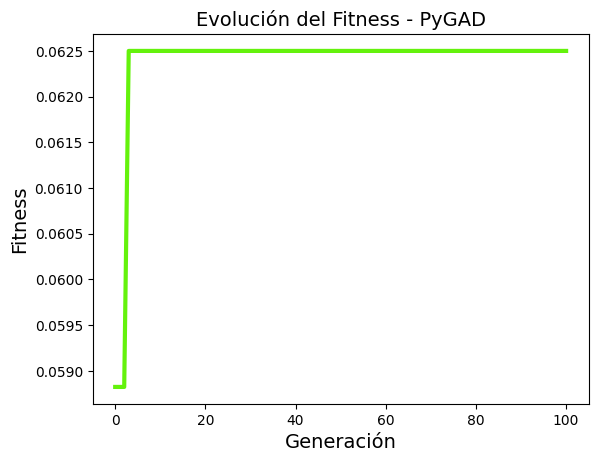

Mejor Solución (orden de prioridad): [7.52926454e+00 9.06905369e-01 2.16286279e+00 4.39659359e+00
 7.36570657e-03 9.70867381e+00 1.81962729e+00 2.13952699e+00
 2.71046866e+00 9.77893340e+00]
Valor de Aptitud: 0.0625
Tiempo total de la obra (Makespan): 16.0 días

Verificación del uso de operarios para la mejor solución:
Tarea 4 (Duración: 5, Operarios: 4) inicia el día 0 y termina el día 5
Tarea 1 (Duración: 7, Operarios: 6) inicia el día 0 y termina el día 7
Tarea 6 (Duración: 3, Operarios: 2) inicia el día 5 y termina el día 8
Tarea 7 (Duración: 2, Operarios: 3) inicia el día 7 y termina el día 9
Tarea 2 (Duración: 4, Operarios: 5) inicia el día 7 y termina el día 11
Tarea 8 (Duración: 4, Operarios: 2) inicia el día 8 y termina el día 12
Tarea 3 (Duración: 6, Operarios: 3) inicia el día 9 y termina el día 15
Tarea 0 (Duración: 5, Operarios: 4) inicia el día 11 y termina el día 16
Tarea 5 (Duración: 4, Operarios: 3) inicia el día 12 y termina el día 16
Tarea 9 (Duración: 2, Operarios: 

In [6]:
# 1. EJECUCIÓN DEL ALGORITMO
# Llama al método run() para iniciar el proceso evolutivo (selección, cruce y mutación)
ga_instance.run()

# 2. VISUALIZACIÓN DEL PROGRESO
# Genera un gráfico que muestra cómo el 'fitness' (aptitud) mejora generación tras generación
ga_instance.plot_fitness(title="Evolución del Fitness - PyGAD", xlabel="Generación", ylabel="Fitness")
plt.show()

# 3. EXTRACCIÓN DE RESULTADOS
# Recupera la mejor combinación encontrada, su valor de fitness y su índice en la población
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Mejor Solución (orden de prioridad): {solution}")
print(f"Valor de Aptitud: {solution_fitness}")

# El 'Makespan' es el tiempo total de obra. Como maximizamos 1/días, aquí calculamos la inversa.
print(f"Tiempo total de la obra (Makespan): {1/solution_fitness} días")

# 4. VERIFICACIÓN Y CRONOGRAMA DETALLADO
# Transformamos los valores del cromosoma en un orden real de tareas usando sus índices
orden_tareas_optimo = np.argsort(solution)

tiempo_actual = 0
# Creamos un calendario vacío (array de días) para registrar el uso de personal
operarios_dia_optimo = np.zeros(int(1/solution_fitness) + 10)

print("\nVerificación del uso de operarios para la mejor solución:")
for tarea_id in orden_tareas_optimo:
    duracion, operarios_necesarios = TASAS_OBRA[tarea_id]

    # Lógica de asignación: Busca el primer día donde la tarea quepa sin superar el límite de 10 operarios
    dia_inicio = 0
    while True:
        disponible = True
        # Revisa cada día de la duración de la tarea
        for d in range(dia_inicio, dia_inicio + duracion):
            if operarios_dia_optimo[d] + operarios_necesarios > MAX_OPERARIOS:
                disponible = False
                dia_inicio += 1 # Si no cabe, intenta empezar un día después
                break
        if disponible:
            break

    # Una vez hallado el día de inicio, 'ocupa' los operarios en esos días del calendario
    for d in range(dia_inicio, dia_inicio + duracion):
        operarios_dia_optimo[d] += operarios_necesarios

    print(f"Tarea {tarea_id} (Duración: {duracion}, Operarios: {operarios_necesarios}) inicia el día {dia_inicio} y termina el día {dia_inicio + duracion}")


# 5. REPORTE DIARIO DE PERSONAL
print("\nUso máximo de operarios por día:")
for dia, uso in enumerate(operarios_dia_optimo):
    if uso > 0:
        print(f"Día {dia}: {uso} operarios")

# 6. VALIDACIÓN FINAL DE RESTRICCIONES
# Comprueba que en ningún momento se haya violado la regla de máximo 10 operarios
max_uso_real = np.max(operarios_dia_optimo)
print(f"\nMáximo de operarios usados en un día: {max_uso_real}")
if max_uso_real <= MAX_OPERARIOS:
    print("¡El límite de operarios no fue excedido!")
else:
    print(f"¡ADVERTENCIA: El límite de operarios fue excedido!")

## Si usan DEAP:

In [7]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt